## 1 Problem statement

A closed thermal-fluid network circulates liquid water through six sequential state points forming a closed loop:

* **State 1 to 2:** Water enters an ideal pump at State 1 and is pressurized to State 2.

* **State 2 to 3:** Water flows through Pipe 1 (length $L = 5\text{ m}$, diameter $D = 0.25\text{ in} 
= 0.00635\text{ m}$) to Heat Exchanger 1.

* **State 3 to 4:** Water is heated in Heat Exchanger 1 with a total heat input of $\dot{Q}_{34} = 100\text{ kW}$.

* **State 4 to 5:** Water flows through Pipe 2 ($L = 5\text{ m}$, $D = 0.25\text{ in}$) to Heat Exchanger 2.

* **State 5 to 6:** Water is cooled in Heat Exchanger 2 down to State 6, where the temperature is $T_6 = 10^\circ\text{C}$.

* **State 6 to 1:** Water returns to the pump entrance through Pipe 3 ($L = 5\text{ m}$, $D = 0.25\text{ in}$).

The system operates at steady state. The Darcy friction factor $f_D$ depends explicitly on flow velocity and Reynolds number. All pressure drops are strictly due to major pipe friction (minor losses from bends are neglected).

## 2 Schematic 

* **CV 1 (Pump):** Encloses states 1 to 2; inputs mechanical work $\dot{W}_p$.

* **CV 2, 4, 6 (Pipes 1, 2, 3):** Enclose branch line segments; evaluate viscous friction pressure drops $\Delta P_f$.

* **CV 3 (HX 1):** Encloses states 3 to 4; inputs heat $\dot{Q}_{34} = 100\text{ kW}$.

* **CV 5 (HX 2):** Encloses states 5 to 6; rejects heat $\dot{Q}_{56}$ to maintain $T_6 = 10^\circ\text{C}$.

## 3 Assumptions

* **Fluid regime:** Subcooled liquid water, incompressible behavior for density evaluations.
* **Flow conditions:** 1D steady-flow throughout the entire loop.
* **Pressure losses:** Frictional head loss occurs only in the straight pipe branches (bends and heat exchanger internals are assumed frictionless).
* **Thermal losses:** Pipe walls are perfectly insulated (adiabatic flow in pipes: $\dot{Q}_{\text{pipe}} = 0$).
* **Heat exchangers:** Isobaric heating (3 to 4) and cooling (5 to 6).

---

## 4 Physical Laws

**Conservation of Mass:**
For steady, 1D flow in a single closed loop, mass flow rate is constant across all nodes:
$$\dot{m}_1 = \dot{m}_2 = \dot{m}_3 = \dot{m}_4 = \dot{m}_5 = \dot{m}_6 = \dot{m}$$


**Constitutive Fluid Relations:**
Local velocity $V$, Reynolds number $Re$, and major friction loss $\Delta P_f$ in any pipe segment depend on local fluid properties ($\rho, \mu$):
$$V = \frac{\dot{m}}{\rho A}, \quad A = \frac{\pi}{4} D^2, \quad Re = \frac{\rho V D}{\mu}$$


Darcy friction factor $f_D$ via Churchill correlation (valid across laminar, transition, and turbulent regimes):
$$f_D = 8 \left[ \left(\frac{8}{Re}\right)^{12} + \frac{1}{(A_c + B_c)^{1.5}} \right]^{1/12}$$


$$\text{where } A_c = \left( -2.457 \ln \left[ \left(\frac{7}{Re}\right)^{0.9} + 0.27 \frac{\epsilon}{D} \right] \right)^{16}, \quad B_c = \left( \frac{37530}{Re} \right)^{16}$$


Major friction pressure drop across pipe length $L$:
$$\Delta P_f = f_D \cdot \frac{L}{D} \cdot \frac{\rho V^2}{2}$$



**Conservation of Momentum (1D Integrated Flow Balance):**

* **Pump ($1 \to 2$):** $P_2 = P_1 + \Delta P_{\text{pump}}(\dot{m})$

* **Pipe 1 ($2 \to 3$):** $P_3 = P_2 - \Delta P_{f,1}$

* **Heat Exchanger 1 ($3 \to 4$):** $P_4 = P_3 \quad (\text{Isobaric})$

* **Pipe 2 ($4 \to 5$):** $P_5 = P_4 - \Delta P_{f,2}$

* **Heat Exchanger 2 ($5 \to 6$):** $P_6 = P_5 \quad (\text{Isobaric})$

* **Pipe 3 ($6 \to 1$):** $P_1 = P_6 - \Delta P_{f,3}$



**Conservation of Energy (First Law of Thermodynamics):**

* **Pump ($1 \to 2$):** $h_2 = h_1 + v_1 (P_2 - P_1)$

* **Pipe 1 ($2 \to 3$):** $h_3 = h_2 $

* **Heat Exchanger 1 ($3 \to 4$):** $\dot{Q}_{34} = \dot{m} (h_4 - h_3)$

* **Pipe 2 ($4 \to 5$):** $h_5 = h_4 $

* **Heat Exchanger 2 ($5 \to 6$):** $\dot{Q}_{56} = \dot{m} (h_6 - h_5)$

* **Pipe 3 ($6 \to 1$):** $h_1 = h_6 $
---



### Solver Formulation

**State Vector Definition**

To solve the closed thermal-fluid network acausally without empirical thermal shortcuts, system unknown properties are gathered into a global state vector $\mathbf{x}$.

The system is formulated as a coupled set of non-linear residual equations $\mathbf{R}(\mathbf{x}) = \mathbf{0}$, driven by real-fluid property evaluations and conservation of mass, momentum, and energy.

---

**1. Hydraulic & Momentum Residual Equations**

Fluid density $\rho_k = \rho(P_k, T_k)$ and dynamic viscosity $\mu_k = \mu(P_k, T_k)$ for each pipe segment $k \in \{23, 45, 61\}$ are evaluated directly from the inlet state thermodynamic equations of state. 

The momentum residuals $R_1$ through $R_6$ enforce pressure continuity around the loop:

* **Pump Head Residual ($R_1$):**

$$R_1 = (P_2 - P_1) - \Delta P_{\text{pump}}(\dot{m})$$

* **Pipe 1 Friction Residual ($R_2$):**

$$R_2 = (P_2 - P_3) - \Delta P_{f,23}(\dot{m}, P_2, T_2)$$

* **Heat Exchanger 1 Isobaric Loss ($R_3$):**

$$R_3 = P_3 - P_4$$

* **Pipe 2 Friction Residual ($R_4$):**

$$R_4 = (P_4 - P_5) - \Delta P_{f,45}(\dot{m}, P_4, T_4)$$

* **Heat Exchanger 2 Isobaric Loss ($R_5$):**

$$R_5 = P_5 - P_6$$

* **Pipe 3 Friction Residual ($R_6$):**

$$R_6 = (P_6 - P_1) - \Delta P_{f,61}(\dot{m}, P_6, T_6)$$

---

**2. Thermal Energy Residual Equations**

Thermodynamic properties are determined at all nodes $i \in \{1, \dots, 6\}$ using `pyCalor`.

Adiabatic pipe transport ($\dot{Q} = 0, \dot{W} = 0$) requires strictly **isenthalpic flow** ($h_{\text{out}} = h_{\text{in}}$). Friction work is converted directly into internal energy, yielding the exact temperature rise without unphysical heat transfer across pipe boundaries.

* **Fixed Node Temperature Boundary ($R_7$):**

$$R_7 = T_6 - 283.15 \quad (\text{enforces } T_6 = 10^\circ\text{C})$$

* **Fixed Reference System Pressure ($R_8$):**

$$R_8 = P_1 - P_{\text{ref}}$$

* **Pipe 3 Adiabatic Transport ($R_9$):**

$$R_9 = h_1(P_1, T_1) - h_6(P_6, T_6)$$

* **Pump Mechanical Energy Balance ($R_{10}$):**

$$R_{10} = h_2(P_2, T_2) - \left[ h_1(P_1, T_1) + v_1(P_1, T_1) \cdot (P_2 - P_1) \right]$$

* **Pipe 1 Adiabatic Transport ($R_{11}$):**

$$R_{11} = h_3(P_3, T_3) - h_2(P_2, T_2)$$

* **Heat Exchanger 1 Energy Balance ($R_{12}$):**

$$R_{12} = \dot{m} \left( h_4(P_4, T_4) - h_3(P_3, T_3) \right) - \dot{Q}_{34} $$

* **Pipe 2 Adiabatic Transport ($R_{13}$):**

$$R_{13} = h_5(P_5, T_5) - h_4(P_4, T_4)$$

Because non-linear state calls $h_i(P_i, T_i)$ and friction factors $f_{D,k}$ depend simultaneously on pressure, temperature, and flow velocity, the system $\mathbf{R}(\mathbf{x}) = \mathbf{0}$ is solved iteratively (Newton-Raphson Numerical Solution Algorithm).

In [6]:
#5 Residual Solver, Code Cell
!pip install pyCalor
import numpy as np
from scipy.optimize import root
from pyCalor import thermo as th

class ThermalFluidNetwork:
    # Acausal thermal-fluid loop solver. Residuals are formulated strictly from First Principles (Conservation of Mass, Momentum, Energy).
    def __init__(self, pipe_length=5.0, pipe_diameter_inch=0.25, roughness=1.5e-6):
        self.L = pipe_length
        self.D = pipe_diameter_inch * 0.0254                   # meters
        self.A = np.pi * (self.D / 2.0)**2
        self.roughness = roughness

    def friction_dp(self, m_dot, st_in):
        # Calculates major friction loss
        rho = 1.0 / st_in.v
        mu = 1.002e-3  # Dynamic viscosity (Pa.s)
        
        v = abs(m_dot) / (rho * self.A)
        Re = (rho * v * self.D) / mu
        if Re < 1e-3: 
            return 0.0, 0.0, 0.0, 0.0
        
        # Churchill correlation for continuous friction factor across flow regimes
        t1 = (-2.457 * np.log((7.0 / Re)**0.9 + 0.27 * (self.roughness / self.D)))**16
        t2 = (37530.0 / Re)**16
        f_D = 8.0 * ((8.0 / Re)**12 + 1.0 / ((t1 + t2)**1.5))**(1/12)
        
        dp_Pa = f_D * (self.L / self.D) * (rho * (v**2) / 2.0)
        return dp_Pa / 1000.0, v, Re, f_D

    def system_residuals(self, X, P1_ref, T6_C, Q34_kW):
        # State Vector X = [m_dot, P2, P3, P4, P5, P6, T4_C]
        m_dot, P2, P3, P4, P5, P6, T4_C = X
        # Residual 7, 8: State 6: Fixed Reference Boundary Condition
        st6 = th.state('water', p=(P6, 'kPa'), t=(T6_C, 'c'), name="6")
        # Residual 9: Pipe 3 (6 -> 1): Adiabatic Flow (Q=0, W=0 -> h1 = h6)
        st1 = th.state('water', p=(P1_ref, 'kPa'), h=st6.h, name="1")
        # Residual 10: Pump (1 -> 2): Ideal Work Input (h2 = h1 + v1 * dP)
        h2 = st1.h + st1.v * (P2 - P1_ref)
        st2 = th.state('water', p=(P2, 'kPa'), h=h2, name="2")
        # Residual 11: Pipe 1 (2 -> 3): Adiabatic Flow (Q=0, W=0 -> h3 = h2)
        st3 = th.state('water', p=(P3, 'kPa'), h=st2.h, name="3")
        # Residual 12: Heat Exchanger 1 (3 -> 4): Isobaric Heating
        st4 = th.state('water', p=(P4, 'kPa'), t=(T4_C, 'c'), name="4")
        # Residual 13: Pipe 2 (4 -> 5): Adiabatic Flow (Q=0, W=0 -> h5 = h4)
        st5 = th.state('water', p=(P5, 'kPa'), h=st4.h, name="5")
        
        # Branch Momentum Losses
        dp_pipe1, _, _, _ = self.friction_dp(m_dot, st2)
        dp_pipe2, _, _, _ = self.friction_dp(m_dot, st4)
        dp_pipe3, _, _, _ = self.friction_dp(m_dot, st6)
        
        # Pump Curve Characteristic
        P_shutoff, K_pump = 3500.0, 8000.0
        
        # Conservation Residual Vector
        R = np.zeros(7)
        # Momentum Conservation
        # Residual 1; when the gauge pressure is equal to the P_shutoff, then the mass flow rate is zero.
        R[0] = (P2 - P1_ref) - (P_shutoff - K_pump * (m_dot**2))
        # Residual 2
        R[1] = (P2 - P3) - dp_pipe1
        # Residual 3
        R[2] = P3 - P4
        # Residual 4
        R[3] = (P4 - P5) - dp_pipe2
        # Residual 5
        R[4] = P5 - P6
        # Residual 6
        R[5] = (P6 - P1_ref) - dp_pipe3
        
        # Energy Conservation across Heat Exchanger 1
        R[6] = m_dot * (st4.h - st3.h) - Q34_kW
        
        return R

    def solve_network(self, x0_guess, p1_base_kPa=2000.0, Q34_kW=100.0, T6_C=10.0):
        sol = root(self.system_residuals, x0_guess, args=(p1_base_kPa, T6_C, Q34_kW), method='hybr')
        
        m_dot, P2, P3, P4, P5, P6, T4_C = sol.x
        
        # Reconstruct exact converged states
        st6 = th.state('water', p=(P6, 'kPa'), t=(T6_C, 'c'), name="6")
        st1 = th.state('water', p=(p1_base_kPa, 'kPa'), h=st6.h, name="1")
        st2 = th.state('water', p=(P2, 'kPa'), h=(st1.h + st1.v * (P2 - p1_base_kPa)), name="2")
        st3 = th.state('water', p=(P3, 'kPa'), h=st2.h, name="3")
        st4 = th.state('water', p=(P4, 'kPa'), t=(T4_C, 'c'), name="4")
        st5 = th.state('water', p=(P5, 'kPa'), h=st4.h, name="5")
        
        # Velocity and friction metrics
        dp1, v1, _, f1 = self.friction_dp(m_dot, st2)
        dp2, v2, _, f2 = self.friction_dp(m_dot, st4)
        dp3, v3, _, f3 = self.friction_dp(m_dot, st6)
        
        for st, v, f in zip([st1, st2, st3, st4, st5, st6], 
                            [v3, v1, v1, v2, v2, v3], 
                            [f3, f1, f1, f2, f2, f3]):
            st.vel = v
            st.f_D = f
            
        W_pump_kW = m_dot * st1.v * (P2 - p1_base_kPa)
        Q56_kW = m_dot * (st6.h - st5.h)
        
        return {
            'm_dot': m_dot,
            'states': [st1, st2, st3, st4, st5, st6],
            'W_pump_kW': W_pump_kW,
            'Q56_kW': Q56_kW
        }

State  P (kPa)     T (°C)    h (kJ/kg)   Velocity (m/s)  f_D       
-------------------------------------------------------------------
1      2000.00     10.21     44.86       10.35           0.0206    
2      4638.39     10.23     47.49       10.34           0.0206    
3      3768.29     10.43     47.49       10.34           0.0206    
4      3768.29     83.40     352.21      10.67           0.0206    
5      2870.82     83.57     352.21      10.67           0.0206    
6      2870.82     10.01     44.86       10.35           0.0206    
-------------------------------------------------------------------
Solved Mass Flow Rate (m_dot) : 0.3282 kg/s
Pump Power Input (W_pump)     : 0.865 kW
Heat Input (Q_34)             : 100.00 kW
Heat Rejected (Q_56)          : -100.865 kW


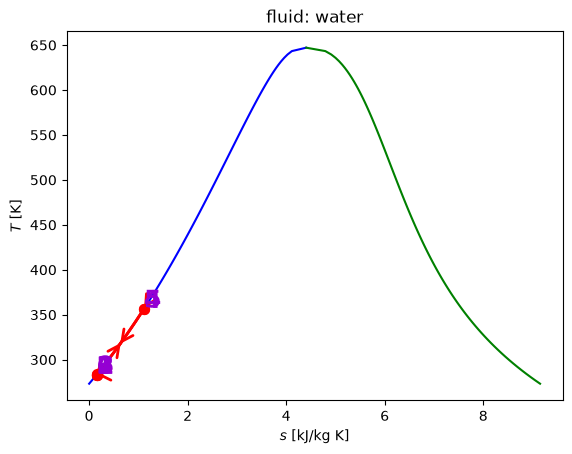

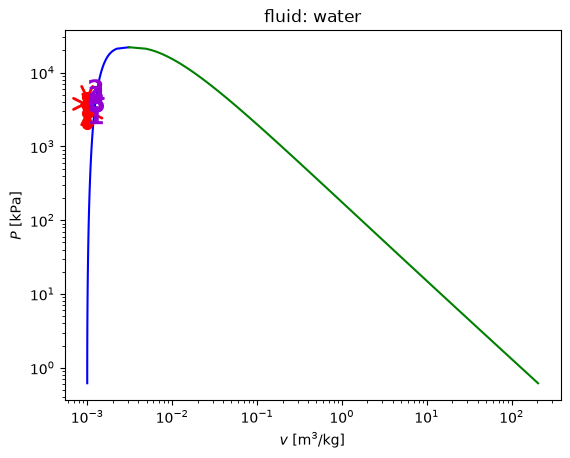

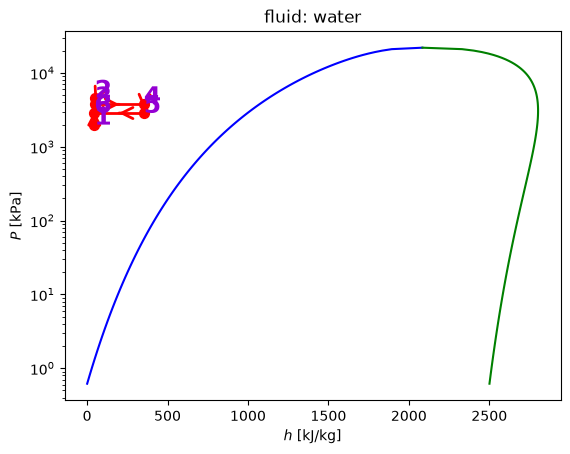

In [11]:
#6 Calculations
# System Parameters
p_base = 2000.0         # Base loop reference pressure at State 1 (kPa)
T6_C = 10.0             # Reference temperature at State 6 (°C)
Q34_kW = 100.0          # Thermal power input at HX 1 (kW)
pipe_length_m = 5.0     # Pipe length (m)
pipe_dia_inch = 0.25    # Pipe diameter (in)

# Initial guess vector [m_dot (kg/s), P2, P3, P4, P5, P6 (kPa), T4 (°C)]
x0_guess = [0.3, 4000.0, 2500.0, 2500.0, 1000.0, 1000.0, 80.0]

# Instantiate and solve
solver = ThermalFluidNetwork(pipe_length=pipe_length_m, pipe_diameter_inch=pipe_dia_inch)
res = solver.solve_network(x0_guess=x0_guess, p1_base_kPa=p_base, Q34_kW=Q34_kW, T6_C=T6_C)

# Display tabular output
print(f"{'State':<7}{'P (kPa)':<12}{'T (°C)':<10}{'h (kJ/kg)':<12}{'Velocity (m/s)':<16}{'f_D':<10}")
print("-" * 67)
for st in res['states']:
    print(f"{st.name:<7}{st.p:<12.2f}{(st.t - 273.15):<10.2f}{st.h:<12.2f}{st.vel:<16.2f}{st.f_D:<10.4f}")

print("-" * 67)
print(f"Solved Mass Flow Rate (m_dot) : {res['m_dot']:.4f} kg/s")
print(f"Pump Power Input (W_pump)     : {res['W_pump_kW']:.3f} kW")
print(f"Heat Input (Q_34)             : {Q34_kW:.2f} kW")
print(f"Heat Rejected (Q_56)          : {res['Q56_kW']:.3f} kW")

# we can plot the process, although it will be hard to visualize because there is no phase change (only in subcooled liquid regime)
st1, st2, st3, st4, st5, st6 = res['states']
pr = th.process([(st1,st2),(st2,st3),(st3,st4),(st4,st5),(st5,st6),(st6,st1)])
fig1 = pr.plot('ts');
fig2 = pr.plot('pv');
fig3 = pr.plot('ph');

---

## 7 Conclusions

* Formulating energy residuals directly through thermodynamic enthalpy guarantees exact global energy conservation. 
* Adiabatic transport conditions ($h_{\text{out}} = h_{\text{in}}$) eliminates unphysical heat leakage across insulated pipe boundaries. Mechanical friction work is converted entirely into internal energy, capturing the physical temperature rise down each transmission line.
* In our formulation, we did not need to compute all of the residuals since we were able to enforce some of them via thermodynamic states (e.g., isenthalpic). 